<a href="https://colab.research.google.com/github/gitirom/5G-Energy-Consumption-Modelling-/blob/Rom_branch/5G_Energy_Concumption_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import LeaveOneGroupOut, GroupShuffleSplit

device = 'cuda' if torch.cuda.is_available() else 'cpu' # detect the GPU if any, if not use CPU, change cuda to mps if you have a mac

In [47]:
device

'cuda'

In [48]:
# from google.colab import drive
# drive.mount('/content/drive')

In [49]:


bs_data = pd.read_csv("/content/drive/MyDrive/PFA_Team/5G-Energy-Consumption-Modelling-Solution-Team-Farzi-Data-Scientists-main/ITU-5G-energy-Consumption-Dataset/BSinfo.csv",)
cl_data = pd.read_csv("/content/drive/MyDrive/PFA_Team/5G-Energy-Consumption-Modelling-Solution-Team-Farzi-Data-Scientists-main/ITU-5G-energy-Consumption-Dataset/CLdata.csv", parse_dates=['Time'])
ec_data = pd.read_csv("/content/drive/MyDrive/PFA_Team/5G-Energy-Consumption-Modelling-Solution-Team-Farzi-Data-Scientists-main/ITU-5G-energy-Consumption-Dataset/ECdata.csv", parse_dates=['Time'])

In [50]:
bs_data

,BS,CellName,RUType,Mode,Frequency,Bandwidth,Antennas,TXpower
0,B_0,Cell0,Type1,Mode2,365.000,20,4,6.875934
1,B_1,Cell0,Type2,Mode2,532.000,20,4,6.875934
2,B_2,Cell0,Type1,Mode2,365.000,20,4,6.875934
3,B_3,Cell0,Type2,Mode2,532.000,20,4,6.875934
4,B_4,Cell0,Type2,Mode2,532.000,20,4,6.875934
...,...,...,...,...,...,...,...,...
1212,B_925,Cell1,Type8,Mode1,697.002,10,4,7.877728
1213,B_105,Cell2,Type1,Mode2,426.980,2,2,6.877429
1214,B_745,Cell2,Type1,Mode2,426.980,2,2,6.877429
1215,B_105,Cell3,Type1,Mode2,426.980,2,2,6.877429


In [51]:
cl_data

,Time,BS,CellName,load,ESMode1,ESMode2,ESMode3,ESMode4,ESMode5,ESMode6
0,2023-01-01 01:00:00,B_0,Cell0,0.487936,0.0,0.0,0.0,0,0.0,0.0
1,2023-01-01 02:00:00,B_0,Cell0,0.344468,0.0,0.0,0.0,0,0.0,0.0
2,2023-01-01 03:00:00,B_0,Cell0,0.193766,0.0,0.0,0.0,0,0.0,0.0
3,2023-01-01 04:00:00,B_0,Cell0,0.222383,0.0,0.0,0.0,0,0.0,0.0
4,2023-01-01 05:00:00,B_0,Cell0,0.175436,0.0,0.0,0.0,0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
125570,2023-01-02 19:00:00,B_745,Cell3,0.071000,0.0,0.0,0.0,0,0.0,0.0
125571,2023-01-02 20:00:00,B_745,Cell3,0.064962,0.0,0.0,0.0,0,0.0,0.0
125572,2023-01-02 21:00:00,B_745,Cell3,0.081865,0.0,0.0,0.0,0,0.0,0.0
125573,2023-01-02 22:00:00,B_745,Cell3,0.097615,0.0,0.0,0.0,0,0.0,0.0


In [52]:
ec_data

,Time,BS,Energy
0,2023-01-01 01:00:00,B_0,64.275037
1,2023-01-01 02:00:00,B_0,55.904335
2,2023-01-01 03:00:00,B_0,57.698057
3,2023-01-01 04:00:00,B_0,55.156951
4,2023-01-01 05:00:00,B_0,56.053812
...,...,...,...
92624,2023-01-02 17:00:00,B_1018,14.648729
92625,2023-01-02 18:00:00,B_1018,14.648729
92626,2023-01-02 21:00:00,B_1018,13.452915
92627,2023-01-02 22:00:00,B_1018,13.602392


In [53]:
#mereg bs and cl

df_merged = cl_data.merge(
    bs_data,
    on=['BS', 'CellName'],
    how='outer'  #keeps all rows from both DataFrames, filling missing values with NaN if there’s no match. outer never drops any row, it just aligns them by your on columns and fills missing values with NaN.
)

In [54]:
df_merged

,Time,BS,CellName,load,ESMode1,ESMode2,ESMode3,ESMode4,ESMode5,ESMode6,RUType,Mode,Frequency,Bandwidth,Antennas,TXpower
0,2023-01-01 01:00:00,B_0,Cell0,0.487936,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.00,20,4,6.875934
1,2023-01-01 02:00:00,B_0,Cell0,0.344468,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.00,20,4,6.875934
2,2023-01-01 03:00:00,B_0,Cell0,0.193766,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.00,20,4,6.875934
3,2023-01-01 04:00:00,B_0,Cell0,0.222383,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.00,20,4,6.875934
4,2023-01-01 05:00:00,B_0,Cell0,0.175436,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.00,20,4,6.875934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125570,2023-01-02 19:00:00,B_999,Cell0,0.077442,0.0,0.0,0.0,0,0.0,0.0,Type5,Mode2,426.98,2,1,6.875934
125571,2023-01-02 20:00:00,B_999,Cell0,0.062808,0.0,0.0,0.0,0,0.0,0.0,Type5,Mode2,426.98,2,1,6.875934
125572,2023-01-02 21:00:00,B_999,Cell0,0.062231,0.0,0.0,0.0,0,0.0,0.0,Type5,Mode2,426.98,2,1,6.875934
125573,2023-01-02 22:00:00,B_999,Cell0,0.052212,0.0,0.0,0.0,0,0.0,0.0,Type5,Mode2,426.98,2,1,6.875934


In [55]:
total_df = df_merged.merge(
    ec_data,
    on=['Time', 'BS'],
    how='outer'
)

In [56]:
total_df

,Time,BS,CellName,load,ESMode1,ESMode2,ESMode3,ESMode4,ESMode5,ESMode6,RUType,Mode,Frequency,Bandwidth,Antennas,TXpower,Energy
0,2023-01-01 01:00:00,B_0,Cell0,0.487936,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,4,6.875934,64.275037
1,2023-01-01 01:00:00,B_1,Cell0,0.034770,0.0,0.0,0.0,0,0.0,0.0,Type2,Mode2,532.0,20,4,6.875934,18.086697
2,2023-01-01 01:00:00,B_10,Cell0,0.010457,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,2,6.875934,30.343797
3,2023-01-01 01:00:00,B_100,Cell0,0.011220,0.0,0.0,0.0,0,0.0,0.0,Type4,Mode2,532.0,20,2,6.875934,NaN
4,2023-01-01 01:00:00,B_101,Cell0,0.008720,0.0,0.0,0.0,0,0.0,0.0,Type4,Mode2,532.0,20,2,6.875934,15.545590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125570,2023-01-08 00:00:00,B_792,Cell0,0.264580,0.0,0.0,0.0,0,0.0,0.0,Type6,Mode2,189.0,10,2,6.427504,NaN
125571,2023-01-08 00:00:00,B_793,Cell0,0.095300,0.0,0.0,0.0,0,0.0,0.0,Type6,Mode2,189.0,10,2,6.427504,18.236173
125572,2023-01-08 00:00:00,B_794,Cell0,0.138851,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,2,6.128550,NaN
125573,2023-01-08 00:00:00,B_795,Cell0,0.537426,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,2,6.875934,47.234679


In [57]:
total_df_Copy = total_df.copy()
total_df_Copy

,Time,BS,CellName,load,ESMode1,ESMode2,ESMode3,ESMode4,ESMode5,ESMode6,RUType,Mode,Frequency,Bandwidth,Antennas,TXpower,Energy
0,2023-01-01 01:00:00,B_0,Cell0,0.487936,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,4,6.875934,64.275037
1,2023-01-01 01:00:00,B_1,Cell0,0.034770,0.0,0.0,0.0,0,0.0,0.0,Type2,Mode2,532.0,20,4,6.875934,18.086697
2,2023-01-01 01:00:00,B_10,Cell0,0.010457,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,2,6.875934,30.343797
3,2023-01-01 01:00:00,B_100,Cell0,0.011220,0.0,0.0,0.0,0,0.0,0.0,Type4,Mode2,532.0,20,2,6.875934,NaN
4,2023-01-01 01:00:00,B_101,Cell0,0.008720,0.0,0.0,0.0,0,0.0,0.0,Type4,Mode2,532.0,20,2,6.875934,15.545590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125570,2023-01-08 00:00:00,B_792,Cell0,0.264580,0.0,0.0,0.0,0,0.0,0.0,Type6,Mode2,189.0,10,2,6.427504,NaN
125571,2023-01-08 00:00:00,B_793,Cell0,0.095300,0.0,0.0,0.0,0,0.0,0.0,Type6,Mode2,189.0,10,2,6.427504,18.236173
125572,2023-01-08 00:00:00,B_794,Cell0,0.138851,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,2,6.128550,NaN
125573,2023-01-08 00:00:00,B_795,Cell0,0.537426,0.0,0.0,0.0,0,0.0,0.0,Type1,Mode2,365.0,20,2,6.875934,47.234679


In [58]:
total_df.duplicated().sum()

np.int64(0)

In [59]:
total_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125575 entries, 0 to 125574
Data columns (total 17 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Time       125575 non-null  datetime64[ns]
 1   BS         125575 non-null  object        
 2   CellName   125575 non-null  object        
 3   load       125575 non-null  float64       
 4   ESMode1    125575 non-null  float64       
 5   ESMode2    125575 non-null  float64       
 6   ESMode3    125575 non-null  float64       
 7   ESMode4    125575 non-null  int64         
 8   ESMode5    125575 non-null  float64       
 9   ESMode6    125575 non-null  float64       
 10  RUType     125575 non-null  object        
 11  Mode       125575 non-null  object        
 12  Frequency  125575 non-null  float64       
 13  Bandwidth  125575 non-null  int64         
 14  Antennas   125575 non-null  int64         
 15  TXpower    125575 non-null  float64       
 16  Energy     98084 non

In [60]:
total_df.describe()

,Time,load,ESMode1,ESMode2,ESMode3,ESMode4,ESMode5,ESMode6,Frequency,Bandwidth,Antennas,TXpower,Energy
count,125575,125575.000000,125575.000000,125575.000000,125575.000000,125575.0,125575.000000,125575.000000,125575.000000,125575.000000,125575.000000,125575.000000,98084.000000
mean,2023-01-03 22:42:31.291260160,0.239009,0.040127,0.036722,0.000085,0.0,0.000011,0.038771,373.535404,15.779144,2.478009,6.744941,28.986888
min,2023-01-01 01:00:00,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,155.600000,2.000000,1.000000,5.381166,0.747384
25%,2023-01-02 09:00:00,0.055080,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,189.000000,10.000000,2.000000,6.427504,18.535127
50%,2023-01-03 17:00:00,0.153410,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,365.000000,20.000000,2.000000,6.875934,24.962631
75%,2023-01-05 12:00:00,0.352220,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,532.000000,20.000000,2.000000,6.875934,37.668161
max,2023-01-08 00:00:00,0.993957,1.000000,1.000000,0.154563,0.0,0.768070,0.931032,979.998000,20.000000,64.000000,8.375336,100.000000
std,NaN,0.235750,0.189631,0.182238,0.002437,0.0,0.002803,0.164538,143.393762,5.762653,4.494594,0.340660,14.345648


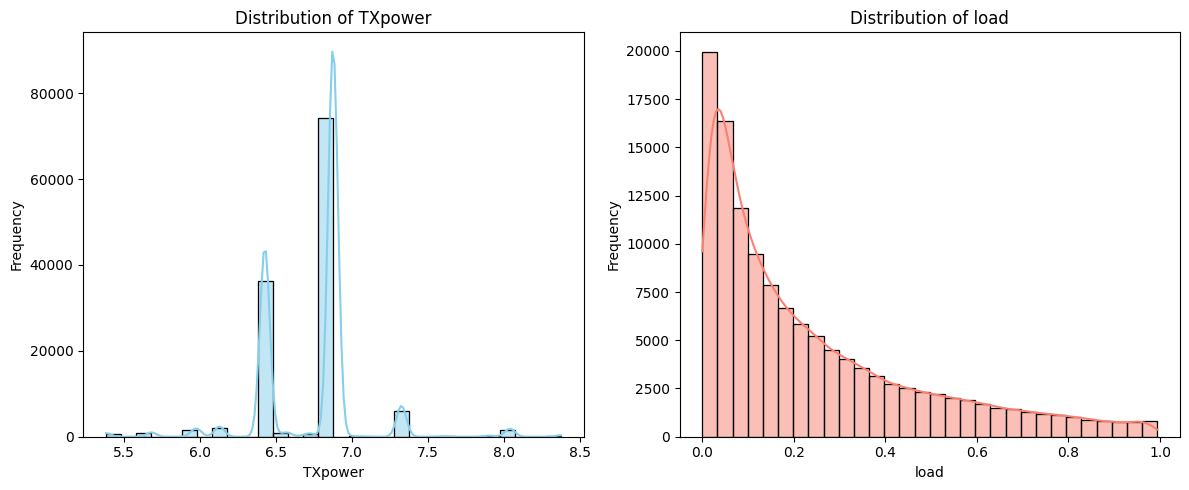

In [61]:


plt.figure(figsize=(12, 5))

# TXpower distribution
plt.subplot(1, 2, 1)  # 1 row, 2 cols, first plot
sns.histplot(total_df['TXpower'], bins=30, kde=True, color='skyblue')
plt.title("Distribution of TXpower")
plt.xlabel('TXpower')
plt.ylabel('Frequency')

# load distribution
plt.subplot(1, 2, 2)
sns.histplot(total_df['load'], bins=30, kde=True, color='salmon')
plt.title("Distribution of load")
plt.xlabel('load')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


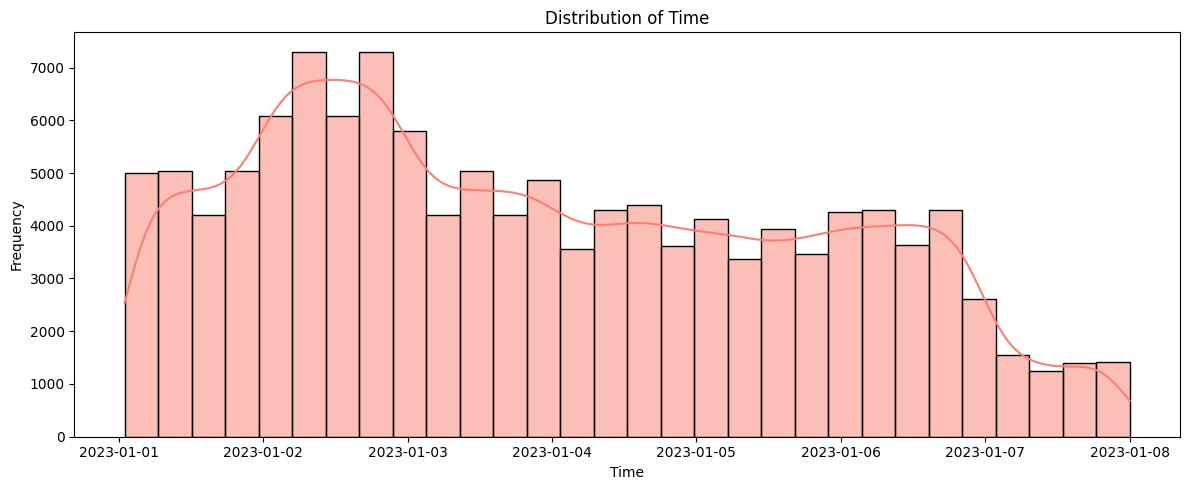

In [62]:


plt.figure(figsize=(12, 5))

sns.histplot(total_df['Time'], bins=30, kde=True, color='salmon')
plt.title("Distribution of Time")
plt.xlabel('Time')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


The distribution **shows a higher concentration of events between January 2nd and 3rd, followed by a gradual decrease towards January 7th–8th**. This suggests temporal clustering of activity earlier in the observed period, potentially influenced by operational or behavioral factors.

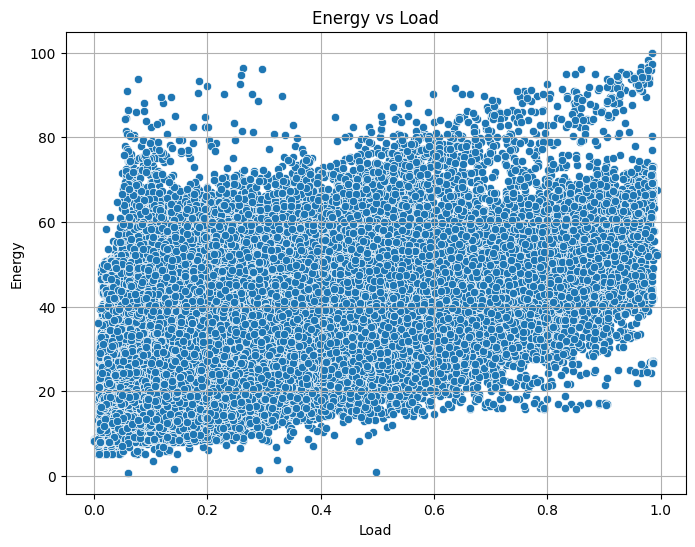

In [63]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="load", y='Energy', data=total_df)
plt.title('Energy vs Load')
plt.xlabel('Load')
plt.ylabel('Energy')
plt.grid(True)
plt.show()


In [64]:
energy_by_load = total_df.groupby('load')['Energy'].agg(['min', 'max', 'mean', 'count']).reset_index()
print(energy_by_load)

           load        min        max       mean  count
0      0.000000   8.221226   8.669656   8.267615     29
1      0.001226        NaN        NaN        NaN      0
2      0.001338        NaN        NaN        NaN      0
3      0.001782        NaN        NaN        NaN      0
4      0.001797        NaN        NaN        NaN      0
...         ...        ...        ...        ...    ...
70500  0.992266  52.167414  52.167414  52.167414      1
70501  0.992457        NaN        NaN        NaN      0
70502  0.993064  67.563528  67.563528  67.563528      1
70503  0.993628        NaN        NaN        NaN      0
70504  0.993957  52.765321  52.765321  52.765321      1

[70505 rows x 5 columns]


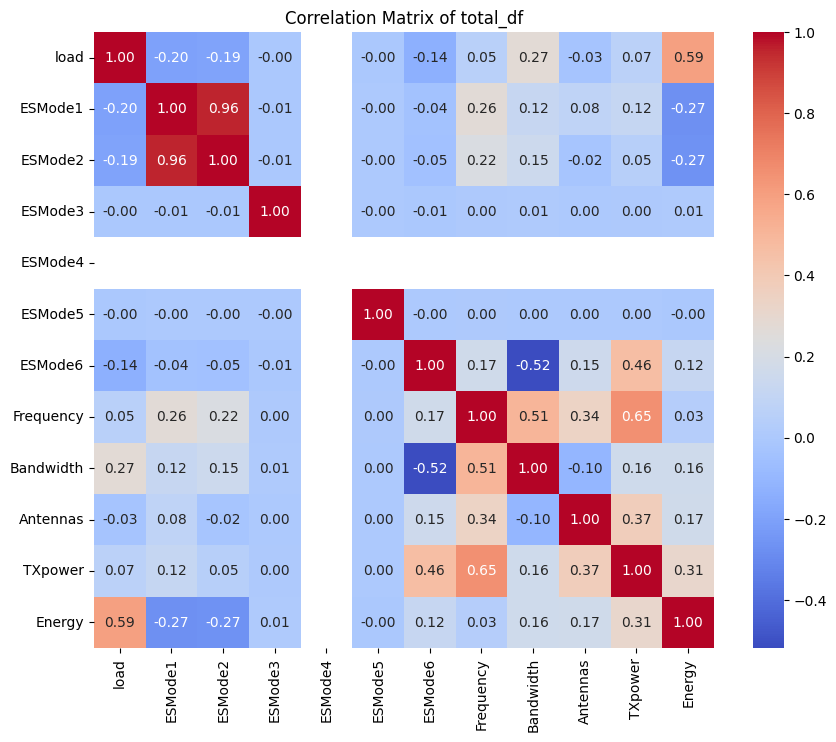

In [65]:
corr_matrix = total_df.select_dtypes('number').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of total_df")
plt.show()

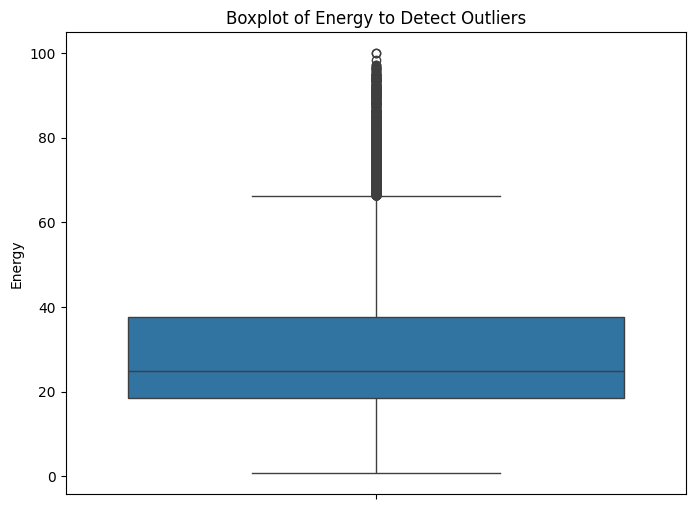

In [66]:
plt.figure(figsize=(8,6))
sns.boxplot(y='Energy', data=total_df)
plt.title('Boxplot of Energy to Detect Outliers')
plt.ylabel('Energy')
plt.show()

**load vs Energy** = 0.595 → moderately strong positive correlation.

*Higher load tends to result in higher energy consumption*, which makes sense physically.

**TXpower vs Energy** = 0.309 → weak-to-moderate positive correlation.

*As transmission power increases, energy consumption increases*, but not as strongly as load.

Other variables like Frequency, Bandwidth, Antennas, and ESMode mostly have weak correlations (<0.2) with Energy.

In [67]:
corrl = total_df.select_dtypes("number").corr()
print(corrl)

               load   ESMode1   ESMode2   ESMode3  ESMode4   ESMode5  \
load       1.000000 -0.198885 -0.192635 -0.003070      NaN -0.003700   
ESMode1   -0.198885  1.000000  0.957473 -0.007346      NaN -0.000830   
ESMode2   -0.192635  0.957473  1.000000 -0.006992      NaN -0.000789   
ESMode3   -0.003070 -0.007346 -0.006992  1.000000      NaN -0.000139   
ESMode4         NaN       NaN       NaN       NaN      NaN       NaN   
ESMode5   -0.003700 -0.000830 -0.000789 -0.000139      NaN  1.000000   
ESMode6   -0.135873 -0.043766 -0.047483 -0.008214      NaN -0.000936   
Frequency  0.053004  0.264829  0.222688  0.004435      NaN  0.004391   
Bandwidth  0.272773  0.122045  0.147595  0.013361      NaN  0.002910   
Antennas  -0.028476  0.084058 -0.022781  0.002282      NaN  0.001345   
TXpower    0.067151  0.115592  0.048987  0.004171      NaN  0.001528   
Energy     0.594971 -0.269606 -0.267593  0.013684      NaN -0.004684   

            ESMode6  Frequency  Bandwidth  Antennas   TXpower  

In [68]:
# assert total_df['ESMode4'].isna().all()

The **assert** will silently pass  

*   **if all values are NaN**
 or raise an
*   **error if NOT all NaN**



In [69]:
print(total_df['ESMode4'].notna().sum())

125575


In [70]:
print(total_df['ESMode4'].value_counts(dropna=False))

ESMode4
0    125575
Name: count, dtype: int64


ESMode4 is **not NaN, it's filled with zeros**. Every single row is 0. This is effectively a **constant column**

Why drop a constant column?

*   Variance = 0 → **model learns nothing from it**



In [71]:
assert (total_df['ESMode4'] == 0).all()

In [72]:
cleaned_df = total_df.drop(columns=['ESMode4'])
print(f"Dropped ESMode4 — was constant (all zeros, {len(total_df)} rows)")
cleaned_df

Dropped ESMode4 — was constant (all zeros, 125575 rows)


,Time,BS,CellName,load,ESMode1,ESMode2,ESMode3,ESMode5,ESMode6,RUType,Mode,Frequency,Bandwidth,Antennas,TXpower,Energy
0,2023-01-01 01:00:00,B_0,Cell0,0.487936,0.0,0.0,0.0,0.0,0.0,Type1,Mode2,365.0,20,4,6.875934,64.275037
1,2023-01-01 01:00:00,B_1,Cell0,0.034770,0.0,0.0,0.0,0.0,0.0,Type2,Mode2,532.0,20,4,6.875934,18.086697
2,2023-01-01 01:00:00,B_10,Cell0,0.010457,0.0,0.0,0.0,0.0,0.0,Type1,Mode2,365.0,20,2,6.875934,30.343797
3,2023-01-01 01:00:00,B_100,Cell0,0.011220,0.0,0.0,0.0,0.0,0.0,Type4,Mode2,532.0,20,2,6.875934,NaN
4,2023-01-01 01:00:00,B_101,Cell0,0.008720,0.0,0.0,0.0,0.0,0.0,Type4,Mode2,532.0,20,2,6.875934,15.545590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125570,2023-01-08 00:00:00,B_792,Cell0,0.264580,0.0,0.0,0.0,0.0,0.0,Type6,Mode2,189.0,10,2,6.427504,NaN
125571,2023-01-08 00:00:00,B_793,Cell0,0.095300,0.0,0.0,0.0,0.0,0.0,Type6,Mode2,189.0,10,2,6.427504,18.236173
125572,2023-01-08 00:00:00,B_794,Cell0,0.138851,0.0,0.0,0.0,0.0,0.0,Type1,Mode2,365.0,20,2,6.128550,NaN
125573,2023-01-08 00:00:00,B_795,Cell0,0.537426,0.0,0.0,0.0,0.0,0.0,Type1,Mode2,365.0,20,2,6.875934,47.234679


In [73]:
cleaned_df.shape

(125575, 16)

=> **Handle ESMode1/2 redundancy**

In [74]:
print(cleaned_df[['ESMode1', 'ESMode2']].describe())

             ESMode1        ESMode2
count  125575.000000  125575.000000
mean        0.040127       0.036722
std         0.189631       0.182238
min         0.000000       0.000000
25%         0.000000       0.000000
50%         0.000000       0.000000
75%         0.000000       0.000000
max         1.000000       1.000000


In [75]:
# 2. How often are they both active at the same time?
both_active = ((cleaned_df['ESMode1'] == 1) & (cleaned_df['ESMode2'] == 1)).sum()
only1 = ((cleaned_df['ESMode1'] == 1) & (cleaned_df['ESMode2'] == 0)).sum()
only2 = ((cleaned_df['ESMode1'] == 0) & (cleaned_df['ESMode2'] == 1)).sum()
neither = ((cleaned_df['ESMode1'] == 0) & (cleaned_df['ESMode2'] == 0)).sum()


print(f"Both active:  {both_active}")
print(f"Only ESMode1: {only1}")
print(f"Only ESMode2: {only2}")
print(f"Neither:      {neither}")


print(f"\nCorrelation: {cleaned_df['ESMode1'].corr(cleaned_df['ESMode2']):.4f}")


Both active:  1614
Only ESMode1: 278
Only ESMode2: 0
Neither:      118982

Correlation: 0.9575




*   ESMode2 never activates independently (always co-occurs with ESMode1)
*   Correlation = 0.957 — near duplicate. Drop ESMode2, keep ESMode1.


## 📊 Feature Pattern Handling Guide

| Pattern | Best Solution |
|--------|---------------|
| ❌ Never both active at the same time (mutually exclusive) | ➜ Combine them → `ESMode_active = ESMode1 + ESMode2` → values become **{0,1,2}** |
| 🔁 Always identical values | ➜ Drop one feature — **pure duplicate** |
| 📈 High correlation (>0.9) | ➜ Drop one feature — **near duplicate** |
| 🔀 Independent, both active sometimes | ➜ Keep both — **each carries unique information** |
| ⚪ One is almost always 0 | ➜ Drop that feature — **near constant** |

In [76]:
cleaned_df = cleaned_df.drop(columns=['ESMode2'])
cleaned_df

,Time,BS,CellName,load,ESMode1,ESMode3,ESMode5,ESMode6,RUType,Mode,Frequency,Bandwidth,Antennas,TXpower,Energy
0,2023-01-01 01:00:00,B_0,Cell0,0.487936,0.0,0.0,0.0,0.0,Type1,Mode2,365.0,20,4,6.875934,64.275037
1,2023-01-01 01:00:00,B_1,Cell0,0.034770,0.0,0.0,0.0,0.0,Type2,Mode2,532.0,20,4,6.875934,18.086697
2,2023-01-01 01:00:00,B_10,Cell0,0.010457,0.0,0.0,0.0,0.0,Type1,Mode2,365.0,20,2,6.875934,30.343797
3,2023-01-01 01:00:00,B_100,Cell0,0.011220,0.0,0.0,0.0,0.0,Type4,Mode2,532.0,20,2,6.875934,NaN
4,2023-01-01 01:00:00,B_101,Cell0,0.008720,0.0,0.0,0.0,0.0,Type4,Mode2,532.0,20,2,6.875934,15.545590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125570,2023-01-08 00:00:00,B_792,Cell0,0.264580,0.0,0.0,0.0,0.0,Type6,Mode2,189.0,10,2,6.427504,NaN
125571,2023-01-08 00:00:00,B_793,Cell0,0.095300,0.0,0.0,0.0,0.0,Type6,Mode2,189.0,10,2,6.427504,18.236173
125572,2023-01-08 00:00:00,B_794,Cell0,0.138851,0.0,0.0,0.0,0.0,Type1,Mode2,365.0,20,2,6.128550,NaN
125573,2023-01-08 00:00:00,B_795,Cell0,0.537426,0.0,0.0,0.0,0.0,Type1,Mode2,365.0,20,2,6.875934,47.234679


In [77]:
cleaned_df.drop(columns=['ESMode5'], inplace=True)
cleaned_df

,Time,BS,CellName,load,ESMode1,ESMode3,ESMode6,RUType,Mode,Frequency,Bandwidth,Antennas,TXpower,Energy
0,2023-01-01 01:00:00,B_0,Cell0,0.487936,0.0,0.0,0.0,Type1,Mode2,365.0,20,4,6.875934,64.275037
1,2023-01-01 01:00:00,B_1,Cell0,0.034770,0.0,0.0,0.0,Type2,Mode2,532.0,20,4,6.875934,18.086697
2,2023-01-01 01:00:00,B_10,Cell0,0.010457,0.0,0.0,0.0,Type1,Mode2,365.0,20,2,6.875934,30.343797
3,2023-01-01 01:00:00,B_100,Cell0,0.011220,0.0,0.0,0.0,Type4,Mode2,532.0,20,2,6.875934,NaN
4,2023-01-01 01:00:00,B_101,Cell0,0.008720,0.0,0.0,0.0,Type4,Mode2,532.0,20,2,6.875934,15.545590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125570,2023-01-08 00:00:00,B_792,Cell0,0.264580,0.0,0.0,0.0,Type6,Mode2,189.0,10,2,6.427504,NaN
125571,2023-01-08 00:00:00,B_793,Cell0,0.095300,0.0,0.0,0.0,Type6,Mode2,189.0,10,2,6.427504,18.236173
125572,2023-01-08 00:00:00,B_794,Cell0,0.138851,0.0,0.0,0.0,Type1,Mode2,365.0,20,2,6.128550,NaN
125573,2023-01-08 00:00:00,B_795,Cell0,0.537426,0.0,0.0,0.0,Type1,Mode2,365.0,20,2,6.875934,47.234679




*   ESMode5 99.997% zeros so drop it:
**Wasted gradient updates, Risk of overfitting on 3 rows**,
*   ESMode6

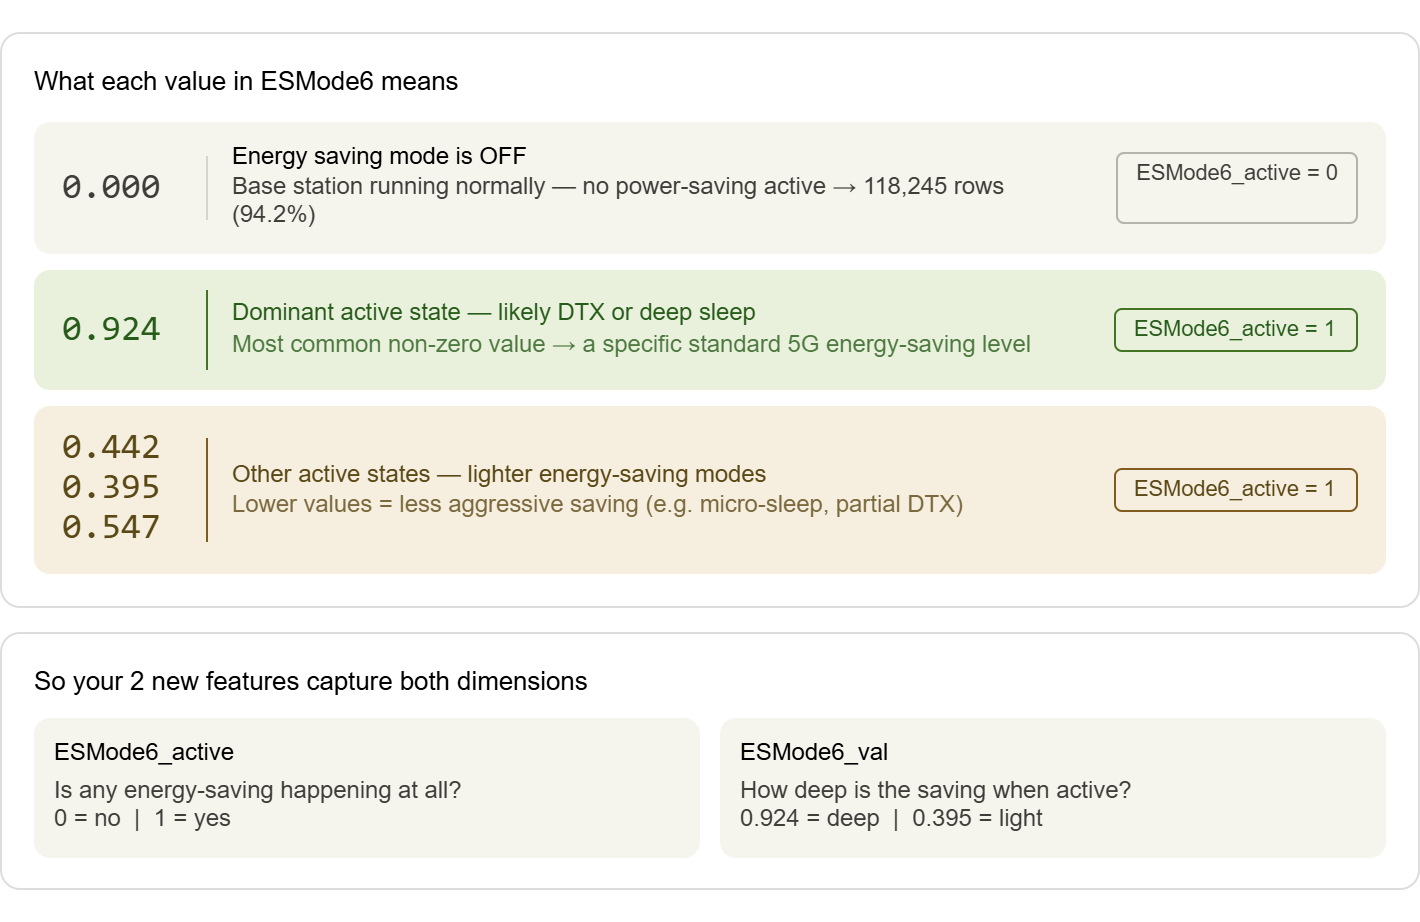


ESMode6_active flag tells the model when a saving mode kicks in, and ESMode6_val tells it how much energy impact to expect from that mode. Together they give your model a much cleaner picture than the raw sparse column ever could.


In [78]:
#define the position of the es6 for getting add the tow new cols in same position
idx = cleaned_df.columns.get_loc('ESMode6')

In [79]:
cleaned_df.insert(idx, 'ESMode6_active', (cleaned_df['ESMode6'] != 0).astype(int))

In [80]:
cleaned_df.insert(idx+1, 'ESMode6_val', cleaned_df['ESMode6'])

In [81]:
cleaned_df.drop(columns=['ESMode6'], inplace=True)

In [82]:
#define the position of the es3 for getting add the tow new cols in same position
idx = cleaned_df.columns.get_loc('ESMode3')

cleaned_df.insert(idx, 'ESMode3_active', (cleaned_df['ESMode3'] != 0).astype(int))

cleaned_df.insert(idx+1, 'ESMode3_val', cleaned_df['ESMode3'])

cleaned_df.drop(columns=['ESMode3'], inplace=True)

In [83]:
cleaned_df


,Time,BS,CellName,load,ESMode1,ESMode3_active,ESMode3_val,ESMode6_active,ESMode6_val,RUType,Mode,Frequency,Bandwidth,Antennas,TXpower,Energy
0,2023-01-01 01:00:00,B_0,Cell0,0.487936,0.0,0,0.0,0,0.0,Type1,Mode2,365.0,20,4,6.875934,64.275037
1,2023-01-01 01:00:00,B_1,Cell0,0.034770,0.0,0,0.0,0,0.0,Type2,Mode2,532.0,20,4,6.875934,18.086697
2,2023-01-01 01:00:00,B_10,Cell0,0.010457,0.0,0,0.0,0,0.0,Type1,Mode2,365.0,20,2,6.875934,30.343797
3,2023-01-01 01:00:00,B_100,Cell0,0.011220,0.0,0,0.0,0,0.0,Type4,Mode2,532.0,20,2,6.875934,NaN
4,2023-01-01 01:00:00,B_101,Cell0,0.008720,0.0,0,0.0,0,0.0,Type4,Mode2,532.0,20,2,6.875934,15.545590
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125570,2023-01-08 00:00:00,B_792,Cell0,0.264580,0.0,0,0.0,0,0.0,Type6,Mode2,189.0,10,2,6.427504,NaN
125571,2023-01-08 00:00:00,B_793,Cell0,0.095300,0.0,0,0.0,0,0.0,Type6,Mode2,189.0,10,2,6.427504,18.236173
125572,2023-01-08 00:00:00,B_794,Cell0,0.138851,0.0,0,0.0,0,0.0,Type1,Mode2,365.0,20,2,6.128550,NaN
125573,2023-01-08 00:00:00,B_795,Cell0,0.537426,0.0,0,0.0,0,0.0,Type1,Mode2,365.0,20,2,6.875934,47.234679


In [84]:
print(cleaned_df['ESMode6_active'].value_counts())
print("----------------------------------------------\n")
print(cleaned_df['ESMode6_val'].value_counts())

print("**************************************************\n")

print(cleaned_df['ESMode3_active'].value_counts())
print("----------------------------------------------\n")
print(cleaned_df['ESMode3_val'].value_counts())

ESMode6_active
0    118245
1      7330
Name: count, dtype: int64
----------------------------------------------

ESMode6_val
0.000000    118245
0.924341         6
0.924342         5
0.924337         3
0.627909         3
             ...  
0.442029         1
0.395009         1
0.460307         1
0.547698         1
0.426347         1
Name: count, Length: 7303, dtype: int64
**************************************************

ESMode3_active
0    125353
1       222
Name: count, dtype: int64
----------------------------------------------

ESMode3_val
0.000000    125353
0.000456         1
0.045823         1
0.000342         1
0.052158         1
             ...  
0.067299         1
0.053396         1
0.018099         1
0.012885         1
0.040264         1
Name: count, Length: 223, dtype: int64


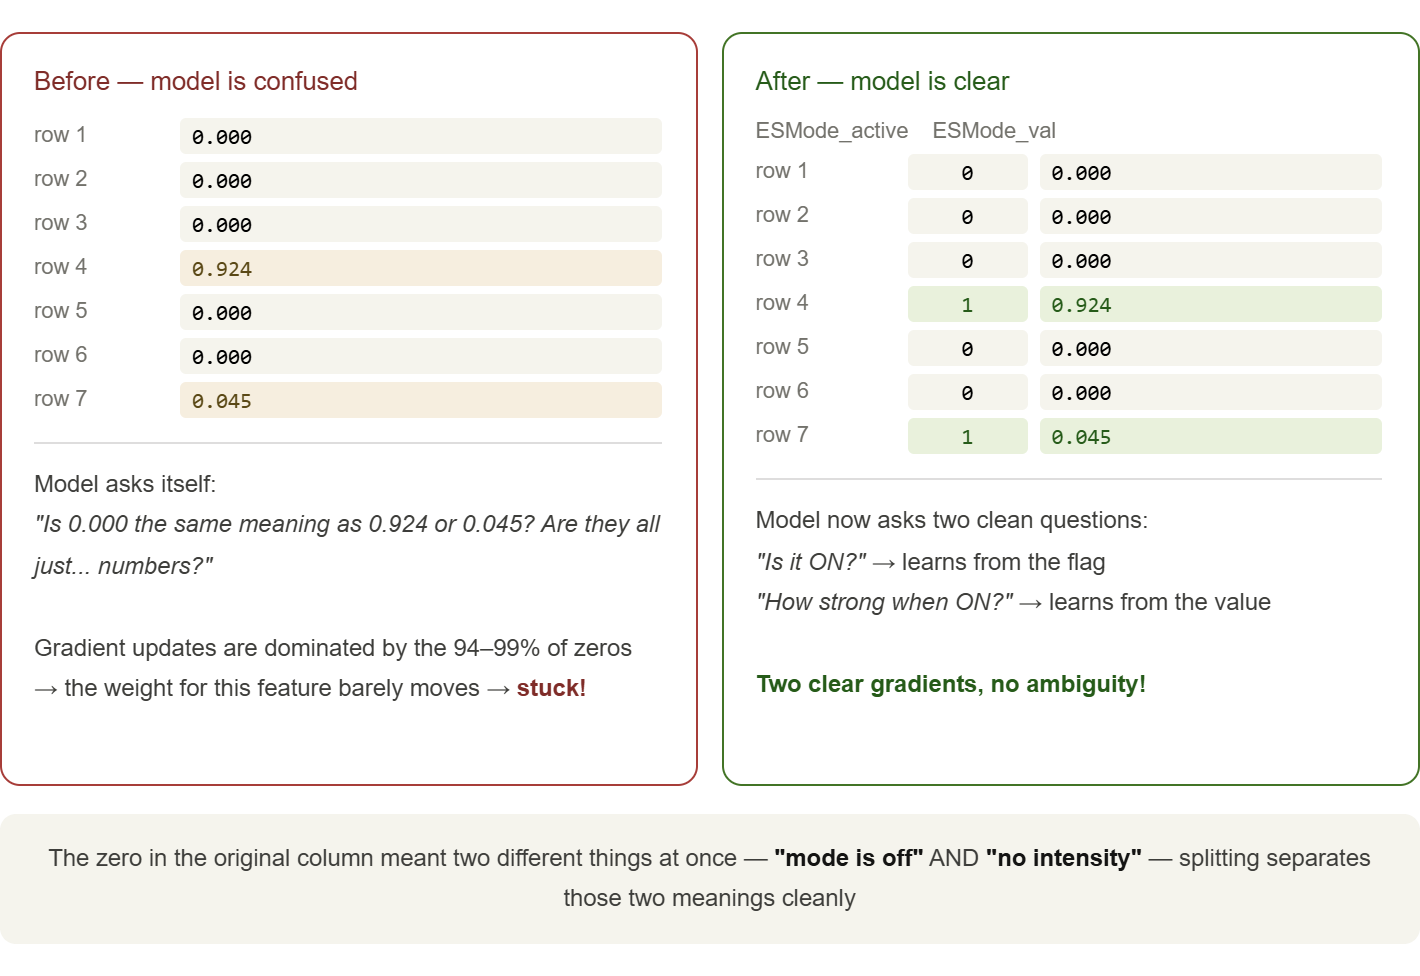



*   Catego's They become **nn.Embedding layers that are part of the neural network**
*   The model **learns the embedding weights during training**



**=> Normalize the numeric vals**

When use N**rmalisation or StanderScaler ?**

| Step | What to Check     | Decision                                                          |
| ---- | ----------------- | ----------------------------------------------------------------- |
| 1    | Model type        | Distance/gradient → **StandardScaler**<br>Tree-based → No scaling |
| 2    | Data distribution | Gaussian → StandardScaler<br>Skewed → **Min-Max Scaling**         |
| 3    | Outliers          | Many outliers → StandardScaler                                    |
| 4    | Range needed      | Need [0–1] → Min-Max Scaling                                      |
| 5    | Feature units     | Different units → StandardScaler                                  |


Time is circular, not linear
*sin & cos convert it into a circle representation*
This **helps your DL model learn patterns correctly**

(sin/cos) approach — it tells the model that hour 23 and hour 0 are neighbors, not opposites.

hour = 0 → (sin=0, cos=1)
hour = 23 → (sin≈-0.26, cos≈0.97)



*   Time column is kept alive through this stage and only dropped after the Goal 1 chronological slice is done




**Target engineering (skew check + log transform)**

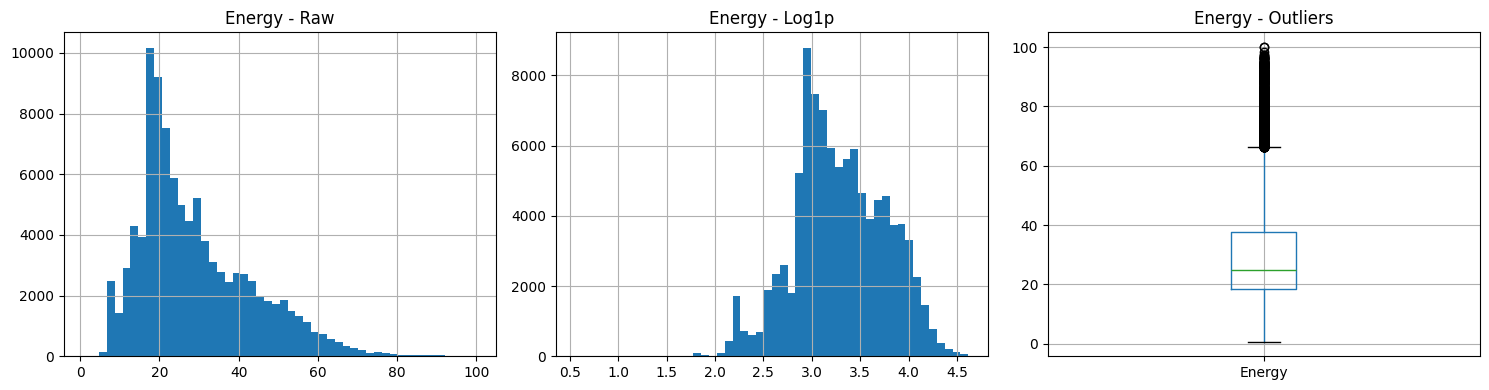

count    98084.000000
mean        28.986888
std         14.345648
min          0.747384
25%         18.535127
50%         24.962631
75%         37.668161
max        100.000000
Name: Energy, dtype: float64
Skewness: 1.007


In [85]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw distribution
cleaned_df['Energy'].hist(bins=50, ax=axes[0])
axes[0].set_title('Energy - Raw')

# Log distribution
np.log1p(cleaned_df['Energy']).hist(bins=50, ax=axes[1])
axes[1].set_title('Energy - Log1p')

# Boxplot for outliers
cleaned_df.boxplot(column='Energy', ax=axes[2])
axes[2].set_title('Energy - Outliers')

plt.tight_layout()
plt.show()

print(cleaned_df['Energy'].describe())
print(f"Skewness: {cleaned_df['Energy'].skew():.3f}")

log1p = safe log transform
**Makes data less skewed**,
**Reduces outlier influence**,
**Improves model learning**

After log:

data More balanced / normal-like

# 3. When evaluating predictions, inverse transform
# predictions_actual = np.expm1(model.predict(X_test))

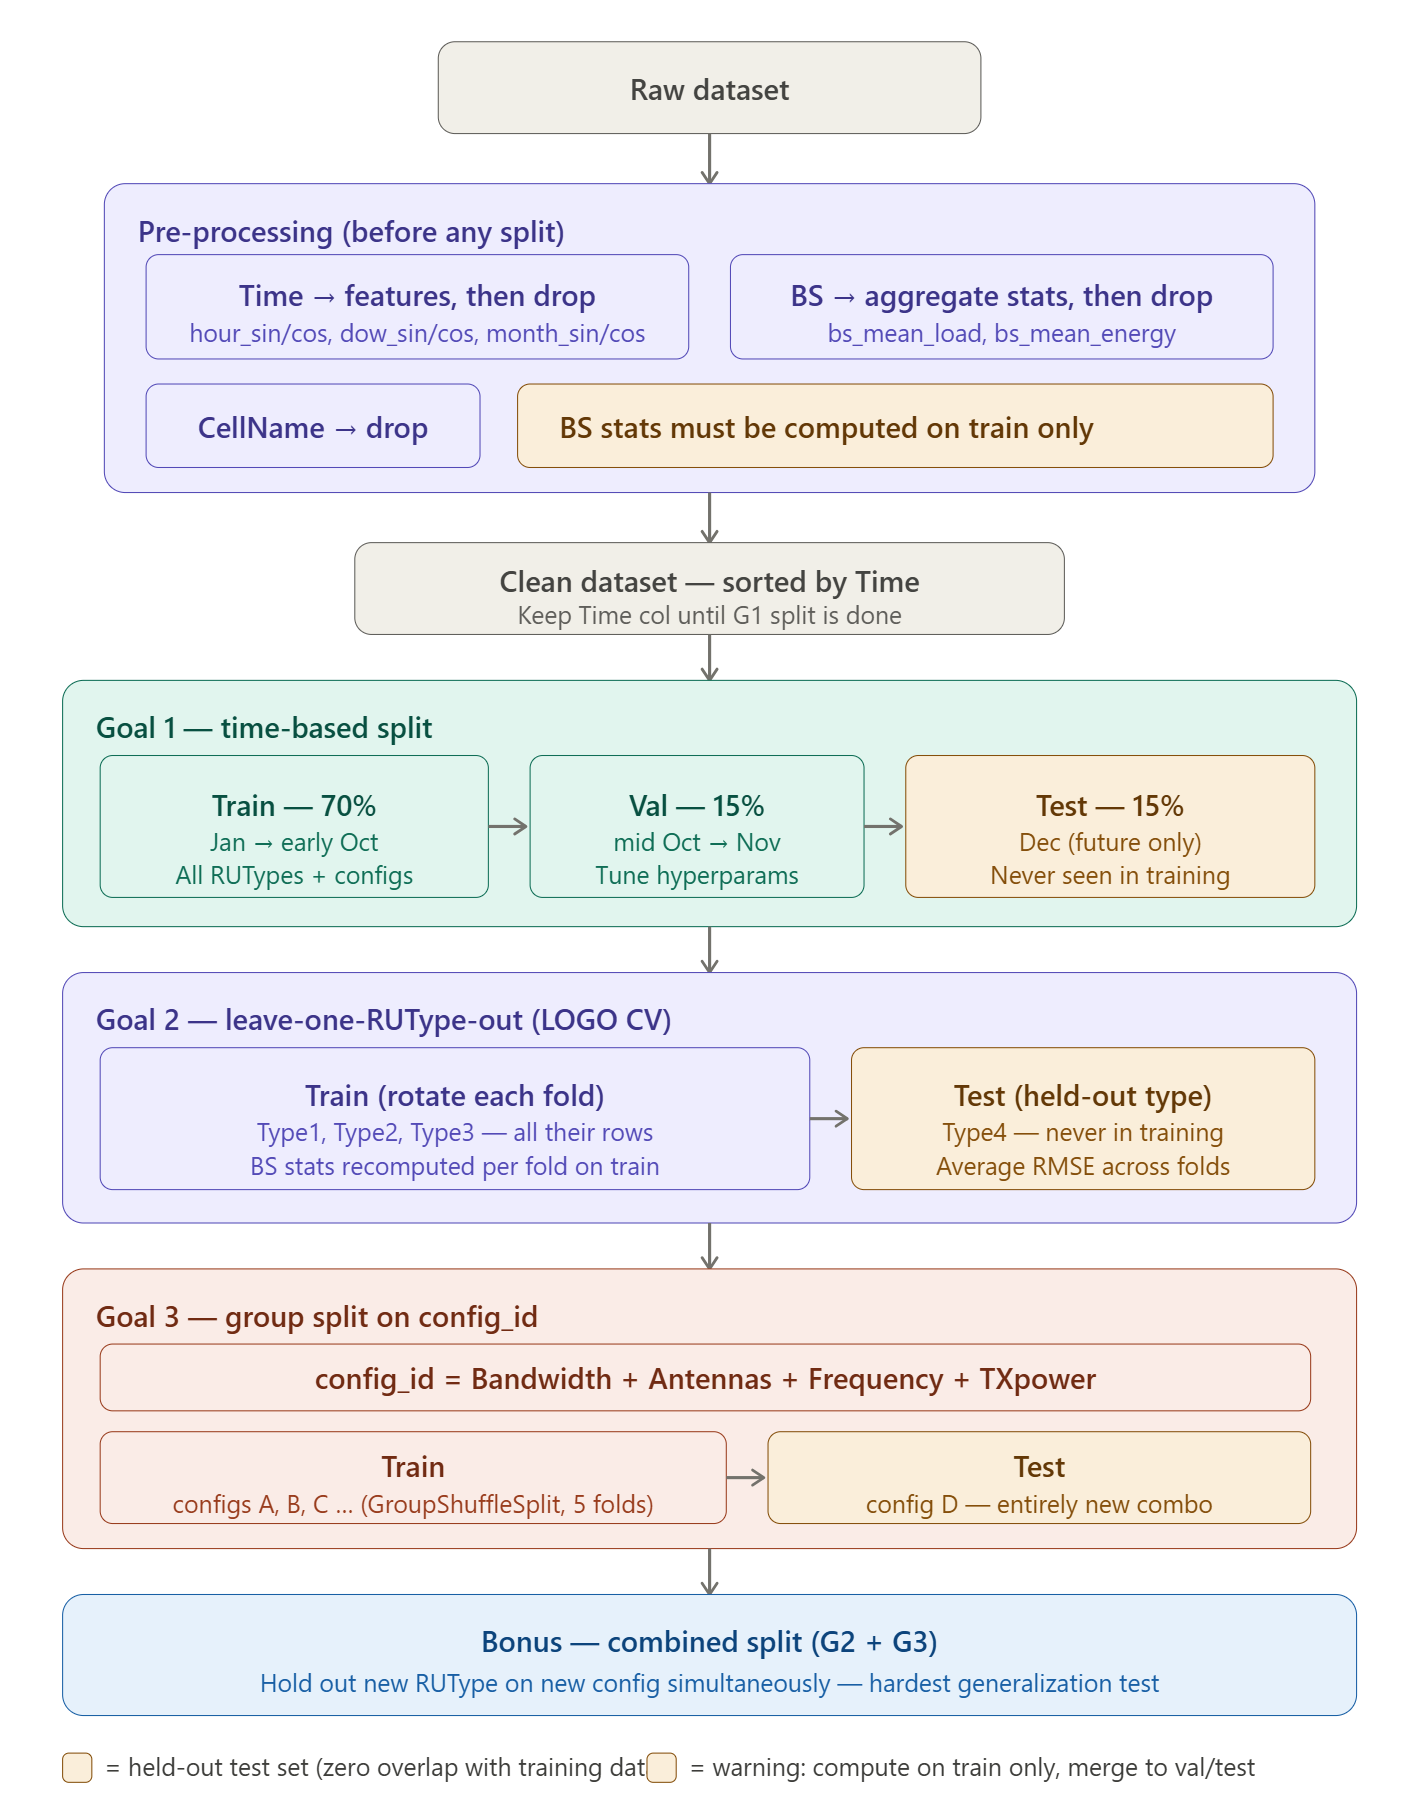hour_sin	hour_cos	dow_sin	dow_cos

***GOAL 1 — TIME-BASED SPLIT***

***Temporal generalization***

cleaned_df  ──────────────────────────────────────────  (never modified)
     │

     ├── train (copy) → add bs_stats → drop Time, BS → X_train, y_train

     ├── val   (copy) → add bs_stats → drop Time, BS → X_val,   y_val

     └── test  (copy) → add bs_stats → drop Time, BS → X_test,  y_test

──────────────────────────────────────────

***GOAL 2 — LEAVE-ONE-RUTYPE-OUT***

**->** ***LeaveOneGroupOut***(): split strategy **split data based on groups in foldes** for the generalisation

If there are **3 unique RUTypes**, you get **3 folds**:
```
Fold 1: train=[TypeB, TypeC]  test=[TypeA]
Fold 2: train=[TypeA, TypeC]  test=[TypeB]
Fold 3: train=[TypeA, TypeB]  test=[TypeC]

```
***GOAL 3 — GROUP SPLIT ON config_id***


**->** ***GroupShuffleSplit***():
```
**GroupShuffleSplit**:
- 🚨​Randomly assigns entire config groups to train or test 🚨​
- Does this n_splits=5 times (5 random folds)
- test_size=0.20 → 20% of configs go to test each fold
- Same config never appears in both train and test ✅
- But it's RANDOM, not "leave one out"

**LeaveOneGroupOut**:
- 🚨​ Every unique config gets its turn as the held-out group 🚨​
- If you have 10 configs → 10 folds
- Exhaustive, not random
```
```
🚨when config_id goes to test fold, ALL its rows go with it, including all their load and ESMode values🚨

config_id = "20_2_1800_40"  ← static hardware identity
    │
    ├── row 1: load=0.3, ESMode1=1, ESMode3=0  ← Monday 8am
    ├── row 2: load=0.7, ESMode1=0, ESMode3=1  ← Monday 9am
    └── row 3: load=0.1, ESMode1=1, ESMode3=1  ← Monday 10am

They are **not configuration identifiers** — they are **time-varying operational features**.
So they just follow the rows wherever they go — train fold or test fold — they're not grouped or split on.

```

**=> Full Pipline**

In [86]:
cleaned_df = cleaned_df.sort_values('Time').reset_index(drop=True)

# ════════════════════════════════════════════════
# 1. PRE-PROCESSING
# ════════════════════════════════════════════════

# ── 1a. Time → cyclical features, keep raw Time for G1 split ──
idx = cleaned_df.columns.get_loc('Time')

cleaned_df['Time'] = pd.to_datetime(cleaned_df['Time'])


cleaned_df.insert(idx+1, 'month', cleaned_df['Time'].dt.month)
cleaned_df.insert(idx+2, 'day_of_week', cleaned_df['Time'].dt.dayofweek)
cleaned_df.insert(idx+3, 'hour', cleaned_df['Time'].dt.hour)


cleaned_df.insert(idx+4, 'hour_sin', np.sin(2 * np.pi * cleaned_df['hour'] / 24))
cleaned_df.insert(idx+5, 'hour_cos', np.cos(2 * np.pi * cleaned_df['hour'] / 24))

cleaned_df.insert(idx+6, 'dow_sin', np.sin(2 * np.pi * cleaned_df['day_of_week'] / 7))
cleaned_df.insert(idx+7, 'dow_cos', np.cos(2 * np.pi * cleaned_df['day_of_week'] / 7))


cleaned_df.insert(idx+8, 'month_sin', np.sin(2 * np.pi * cleaned_df['month'] / 12))
cleaned_df.insert(idx+9, 'month_cos', np.cos(2 * np.pi * cleaned_df['month'] / 12))

cleaned_df.drop(columns=["hour", "day_of_week", "month"], inplace=True)

cleaned_df.drop(columns=["CellName"], inplace=True)

# ── 1c. Target → log-transform
cleaned_df["Energy_Log"] = np.log1p(cleaned_df["Energy"])
cleaned_df.drop(columns=["Energy"], inplace=True)

cleaned_df.dropna(subset=["Energy_Log"], inplace=True)
cleaned_df.reset_index(drop=True, inplace=True)

print(f"Dataset shape after pre-processing: {cleaned_df.shape}")
print(f"Columns: {cleaned_df.columns.tolist()}")

# ════════════════════════════════════════════════
# 2. DEFINE FEATURES & TARGET
# ════════════════════════════════════════════════

FEATURES = [
    "hour_sin", "hour_cos",
    "dow_sin",  "dow_cos",
    "month_sin","month_cos",
    #Network load & energy saving modes
    "load",
    "ESMode1",
    "ESMode3_active", "ESMode3_val",
    "ESMode6_active", "ESMode6_val",
    # Tower identity & configuration
    "RUType", "Mode", "Frequency",
    "Bandwidth", "Antennas", "TXpower",
    # BS-level aggregates
    "bs_mean_load", "bs_mean_energy",
]

TARGET = "Energy_Log"

# ════════════════════════════════════════════════
# 3. BS STATS HELPER  (train-only, then merge)
# ════════════════════════════════════════════════

def add_bs_stats(train_df, apply_df):
  """
    Compute per-BS aggregates on train_df only,
    then merge onto apply_df (val or test).
    Never compute on the full dataset — that leaks future info.
  """

  bs_stats = (
      train_df.groupby("BS")
      .agg(
          bs_mean_load=("load", "mean"),
          bs_mean_energy=(TARGET, "mean")
      )
      .reset_index()
  )

  # Left merge — unseen BS IDs in val/test get NaN → fill with global mean
  global_load   = train_df["load"].mean()
  global_energy = train_df[TARGET].mean()

  result = apply_df.merge(bs_stats, on="BS", how="left")
  result["bs_mean_load"].fillna(global_load,   inplace=True)
  result["bs_mean_energy"].fillna(global_energy, inplace=True)
  return result

# ════════════════════════════════════════════════
# 4. GOAL 1 — TIME-BASED SPLIT
# ════════════════════════════════════════════════
def split_goal1(cleaned_df, train_ratio=0.70, val_ratio=0.15):
  n = len(cleaned_df)
  train_end = int(n * train_ratio)
  val_end = int(n * (train_ratio + val_ratio))

  train = cleaned_df.iloc[:train_end].copy()
  val = cleaned_df.iloc[train_end:val_end].copy()
  test = cleaned_df.iloc[val_end:].copy()

   # Add BS stats (computed on train only)
  train = add_bs_stats(train, train)
  val   = add_bs_stats(train, val)
  test  = add_bs_stats(train, test)

  # Now safe to drop Time and BS
  for split in [train, val, test]:
    split.drop(columns=["Time", "BS"], inplace=True)


  X_train = train[FEATURES]; y_train = train[TARGET]
  X_val   = val[FEATURES];   y_val   = val[TARGET]
  X_test  = test[FEATURES];  y_test  = test[TARGET]

  print("\n── Goal 1: Time-based split ──")
  print(f"  Train : {len(X_train):>6} rows")
  print(f"  Val   : {len(X_val):>6} rows")
  print(f"  Test  : {len(X_test):>6} rows")

  return X_train, X_val, X_test, y_train, y_val, y_test


X_train_g1, X_val_g1, X_test_g1, \
y_train_g1, y_val_g1, y_test_g1 = split_goal1(cleaned_df)




# ════════════════════════════════════════════════
# 5. GOAL 2 — LEAVE-ONE-RUTYPE-OUT
# ════════════════════════════════════════════════

def split_goal2(cleaned_df):
  logo = LeaveOneGroupOut()
  groups = cleaned_df["RUType"]
  folds  = []

  print("\n── Goal 2: Leave-One-RUType-Out ──")
  '''
    logo.split() returns index arrays — not data, just row positions.
    tr_idx → indices of training data
    te_idx → indices of test data

    👉 The split ensures:

    Train = all RU types except one
    Test = only the held-out RU type

  '''
  for fold, (tr_idx, te_idx) in enumerate(logo.split(cleaned_df, cleaned_df[TARGET], groups)):
    train_fold = cleaned_df.iloc[tr_idx].copy()
    test_fold  = cleaned_df.iloc[te_idx].copy()
    held_type  = test_fold["RUType"].unique()[0]  #Which RUType is the model tested on (unseen)

    # BS stats recomputed inside this fold's train
    train_fold = add_bs_stats(train_fold, train_fold)
    test_fold  = add_bs_stats(train_fold, test_fold)

    '''
      👉 So:

        Train stats → computed from train
        Test stats → use train statistics only

        🚫 Prevents data leakage
    '''

    for split in [train_fold, test_fold]:
      split.drop(columns=["Time", "BS"], inplace=True)

    folds.append({
        "held_type": held_type,
        "X_train":   train_fold[FEATURES],
        "y_train":   train_fold[TARGET],
        "X_test":    test_fold[FEATURES],
        "y_test":    test_fold[TARGET],
    })

    '''
      Each fold contains:

      Features (X)
      Target (y)
      Info about which RUType is held out
    '''

    print(f"  Fold {fold+1}: held out [{held_type}] — "
              f"train {len(train_fold)} rows | test {len(test_fold)} rows")

  return folds

folds_g2 = split_goal2(cleaned_df)

# ── Use a single fold ──

fold = folds_g2[0]
X_train_g2, y_train_g2 = fold["X_train"], fold["y_train"]
X_test_g2,  y_test_g2  = fold["X_test"],  fold["y_test"]



# ════════════════════════════════════════════════
# 6. GOAL 3 — GROUP SPLIT ON config_id
# ════════════════════════════════════════════════

def split_goal3(df, n_splits=5, test_size=0.20, random_state=42):
  df = cleaned_df.copy()
  df["config_id"] = (
      df["Bandwidth"].astype(str) + "_" +
      df["Antennas"].astype(str)  + "_" +
      df["Frequency"].astype(str) + "_" +
      df["TXpower"].astype(str)
  )

  gss = GroupShuffleSplit(n_splits=n_splits,
                          test_size=test_size,
                          random_state=random_state)

  groups = df["config_id"]
  folds = []

  print(f"\n── Goal 3: Group split on config_id ──")
  print(f"  Total unique configs: {groups.nunique()}")

  for fold, (tr_idx, te_idx) in enumerate(gss.split(df, df[TARGET], groups)):
    train_fold = df.iloc[tr_idx].copy()
    test_fold  = df.iloc[te_idx].copy()

    train_fold = add_bs_stats(train_fold, train_fold)
    test_fold  = add_bs_stats(train_fold, test_fold)

    for split in [train_fold, test_fold]:
      split.drop(columns=["Time", "BS", "config_id"], inplace=True)

    held = df.iloc[te_idx]["config_id"].unique()

    folds.append({
            "held_configs": held,
            "X_train":      train_fold[FEATURES],
            "y_train":      train_fold[TARGET],
            "X_test":       test_fold[FEATURES],
            "y_test":       test_fold[TARGET],
        })

    print(f"  Fold {fold+1}: {len(held)} configs held out — "
            f"train {len(train_fold)} rows | test {len(test_fold)} rows")

  return folds

folds_g3 = split_goal3(cleaned_df)


fold     = folds_g3[0]
X_train_g3, y_train_g3 = fold["X_train"], fold["y_train"]
X_test_g3,  y_test_g3  = fold["X_test"],  fold["y_test"]




Dataset shape after pre-processing: (98084, 21)
Columns: ['Time', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'BS', 'load', 'ESMode1', 'ESMode3_active', 'ESMode3_val', 'ESMode6_active', 'ESMode6_val', 'RUType', 'Mode', 'Frequency', 'Bandwidth', 'Antennas', 'TXpower', 'Energy_Log']

── Goal 1: Time-based split ──
  Train :  68658 rows
  Val   :  14713 rows
  Test  :  14713 rows

── Goal 2: Leave-One-RUType-Out ──


/tmp/ipykernel_2048/374870648.py:89: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  result["bs_mean_load"].fillna(global_load,   inplace=True)
/tmp/ipykernel_2048/374870648.py:90: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

  Fold 1: held out [Type1] — train 73889 rows | test 24195 rows
  Fold 2: held out [Type10] — train 97681 rows | test 403 rows
  Fold 3: held out [Type11] — train 98083 rows | test 1 rows


/tmp/ipykernel_2048/374870648.py:89: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  result["bs_mean_load"].fillna(global_load,   inplace=True)
/tmp/ipykernel_2048/374870648.py:90: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

  Fold 4: held out [Type12] — train 98083 rows | test 1 rows
  Fold 5: held out [Type2] — train 94223 rows | test 3861 rows
  Fold 6: held out [Type3] — train 92622 rows | test 5462 rows


...

/tmp/ipykernel_2048/374870648.py:89: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  result["bs_mean_load"].fillna(global_load,   inplace=True)
/tmp/ipykernel_2048/374870648.py:90: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

  Fold 11: held out [Type8] — train 97834 rows | test 250 rows
  Fold 12: held out [Type9] — train 97566 rows | test 518 rows

── Goal 3: Group split on config_id ──
  Total unique configs: 55
  Fold 1: 11 configs held out — train 73436 rows | test 24648 rows


/tmp/ipykernel_2048/374870648.py:89: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  result["bs_mean_load"].fillna(global_load,   inplace=True)
/tmp/ipykernel_2048/374870648.py:90: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

  Fold 2: 11 configs held out — train 93556 rows | test 4528 rows
  Fold 3: 11 configs held out — train 72497 rows | test 25587 rows
  Fold 4: 11 configs held out — train 93998 rows | test 4086 rows
  Fold 5: 11 configs held out — train 89955 rows | test 8129 rows


/tmp/ipykernel_2048/374870648.py:89: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  result["bs_mean_load"].fillna(global_load,   inplace=True)
/tmp/ipykernel_2048/374870648.py:90: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tr

✅ Clean Explanation of BS extraction

👉 We don’t use the raw **BS ID because it’s just an identifier with no inherent meaning** and high cardinality, which** leads to overfitting.**

👉 Instead, we **replace it with aggregated features** like:

**bs_mean_load**
**bs_mean_energy**

These **capture the behavior of each station**, which is what actually matters for prediction.

🔒 Why only compute on training data?

Because otherwise:

The aggregates would include future (test) information
This **creates data leakage**

👉 So:

**Train set → compute stats**

**Apply same stats → train + test**

**=> Data Splitting**
data splitting before scale num cols to **avoid data leakage**